PRÁCTICA MACHINE LEARNING: Predecir el mercado de valores

 ¡Hola y bienvenido a la Práctica de Machine Learning más difícil del mundo!

Este notebook está diseñado para ayudarte a comenzar con la práctica.

En este cuaderno vamos a:

- Descargar y explorar el conjunto de datos
- Entrenar y evaluar este primer modelo de aprendizaje automático
- Implementar el modelo para comenzar a realizar predicciones

In [30]:
# Instala dependencias
!pip install -q --upgrade numerapi pandas pyarrow matplotlib lightgbm scikit-learn scipy cloudpickle==3.1.1
!pip install -q --no-deps numerai-tools

# Gráficas Inline
%matplotlib inline


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


1.- DATASET

A alto nivel, trabajaremos con un conjunto de datos tabulares que describe el mercado de valores a lo largo del tiempo.

Cada fila representa una acción en un momento específico, donde "id" es la identificación de la acción y "era" es la fecha. 

Las características describen los atributos de la acción (por ejemplo, el ratio Price/Earning) conocidos en una fecha dada, y "target" es una medida de rendimientos a 20 días.

El conjunto de datos está ofuscado, lo que significa que los identificadores de acciones (stocks) subyacentes, los nombres de las características y las definiciones de objetivos son anónimos. Esto hace que podamos trabajar con estos datos de forma gratuita y que puedan modelarse sin ningún conocimiento (¡o sesgo!) del dominio financiero.

Descargamos los datos históricos de entrenamiento y echamos un vistazo de cerca.

In [31]:
# Inicializa NumerAPI - el cliente oficial de Python para acceder al API de nuestro conjunto de datos.
from numerapi import NumerAPI
napi = NumerAPI()

# Set data version to one of the latest datasets
DATA_VERSION = "v5.0"

# Imprime todos los ficheros del conjunto de datos disponibles para descargar los más recientes.
[f for f in napi.list_datasets() if f.startswith(DATA_VERSION)]

['v5.0/features.json',
 'v5.0/live.parquet',
 'v5.0/live_benchmark_models.parquet',
 'v5.0/live_example_preds.csv',
 'v5.0/live_example_preds.parquet',
 'v5.0/meta_model.parquet',
 'v5.0/train.parquet',
 'v5.0/train_benchmark_models.parquet',
 'v5.0/validation.parquet',
 'v5.0/validation_benchmark_models.parquet',
 'v5.0/validation_example_preds.csv',
 'v5.0/validation_example_preds.parquet']

In [32]:
import pandas as pd
import json

# Descarga los datos de entrenamiento y los metadatos de las características
# Esto tomará unos pocos minutos 🍵
napi.download_dataset(f"{DATA_VERSION}/train.parquet");
napi.download_dataset(f"{DATA_VERSION}/features.json");

# Carga solo el conjunto de features "medium" para reducir el uso de memoria y acelerar el entrenamiento del modelo 
# O bien, utiliza el conjunto de features "all" para usar todas las características
# En este ejemplo descargaremos solo el "small"
feature_metadata = json.load(open(f"{DATA_VERSION}/features.json"))
feature_sets = feature_metadata["feature_sets"]
for feature_set in ["small", "medium", "all"]:
  print(feature_set, len(feature_sets[feature_set]))

feature_set = feature_sets["small"]
#feature_cols = feature_metadata["feature_sets"]["small"]
#train = pd.read_parquet(f"{DATA_VERSION}/train.parquet", columns=["era"] + feature_cols + ["target"])
train = pd.read_parquet(
    f"{DATA_VERSION}/train.parquet",
    columns=["era", "target"] + feature_set
)

# Reduce la muestra, tomando cada cuatro eras, para reducir el uso de memoria y acelerar el entrenamiento del modelo (toma las eras 0001, 0005, 0009, ...)
# Comenta la línea a continuación para utilizar todos los datos.
#train = train[train["era"].isin(train["era"].unique()[::4])]
train

2025-11-04 12:25:42,142 INFO numerapi.utils: target file already exists
2025-11-04 12:25:42,147 INFO numerapi.utils: download complete
2025-11-04 12:25:43,081 INFO numerapi.utils: target file already exists
2025-11-04 12:25:43,084 INFO numerapi.utils: download complete


small 42
medium 705
all 2376


,era,target,feature_antistrophic_striate_conscriptionist,feature_bicameral_showery_wallaba,feature_bridal_fingered_pensioner,feature_collectivist_flaxen_gueux,feature_concurring_fabled_adapter,feature_crosscut_whilom_ataxy,feature_departmental_inimitable_sentencer,feature_dialectal_homely_cambodia,...,feature_tridactyl_immoral_snorting,feature_trimeter_soggy_greatest,feature_unanalyzable_excusable_whirlwind,feature_unbreakable_constraining_hegelianism,feature_unformed_bent_smatch,feature_unministerial_unextenuated_teleostean,feature_unmodish_zymogenic_rousing,feature_unsystematized_subcardinal_malaysia,feature_willful_sere_chronobiology,feature_zoological_peristomial_scute
id,,,,,,,,,,,,,,,,,,,,,
n0007b5abb0c3a25,0001,0.25,2,2,2,2,2,0,1,2,...,4,1,1,3,0,2,2,3,3,2
n003bba8a98662e4,0001,0.25,2,2,2,2,2,1,4,2,...,4,2,0,0,0,2,2,4,4,2
n003bee128c2fcfc,0001,0.75,2,2,2,2,2,2,2,2,...,3,1,1,0,1,2,2,0,3,2
n0048ac83aff7194,0001,0.25,2,2,2,2,2,1,4,2,...,1,3,4,1,2,2,2,2,0,2
n0055a2401ba6480,0001,0.25,2,2,2,2,2,0,0,2,...,1,0,1,0,0,2,2,1,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nffcc1dbdf2212e6,0574,0.75,1,3,0,0,0,4,3,1,...,2,3,4,2,4,3,2,3,3,3
nffde3b371d67394,0574,0.25,2,3,4,4,2,2,4,2,...,2,4,4,3,4,2,1,4,4,2
nfff1a1111b35e84,0574,0.50,0,0,2,1,4,0,0,4,...,4,0,0,0,0,4,4,0,0,2


In [33]:
from sklearn.model_selection import train_test_split

# X son las features, y es el target
X = train[feature_set]
y = train["target"]

# 80% para entrenamiento, 20% para test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Gracias a Train_test_split dividimos nuestro conjunto de datos en un 80% para entrenamiento y un 20% para test

**Reducción del número de eras y su impacto en el rendimiento**

Aunque reducir las eras es útil para experimentar y ajustar el modelo rápidamente, para obtener el mejor rendimiento final es recomendable entrenar con la mayor cantidad de datos posible. Porque como podemos comprobar el rendimiento se ve afectado debido a la reducción de eras en los datos.

A la izquierda la imagen con todos los datos y a la derecha la imagen con los datos reducidos

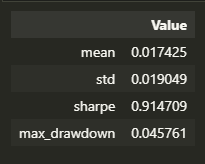 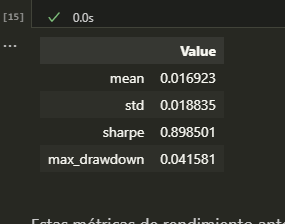


### Exploración visual del dataset
A continuación se muestran varias gráficas para comprender mejor la estructura y distribución de los datos. Estas visualizaciones ayudan a detectar posibles problemas, patrones y a justificar decisiones de preprocesamiento.

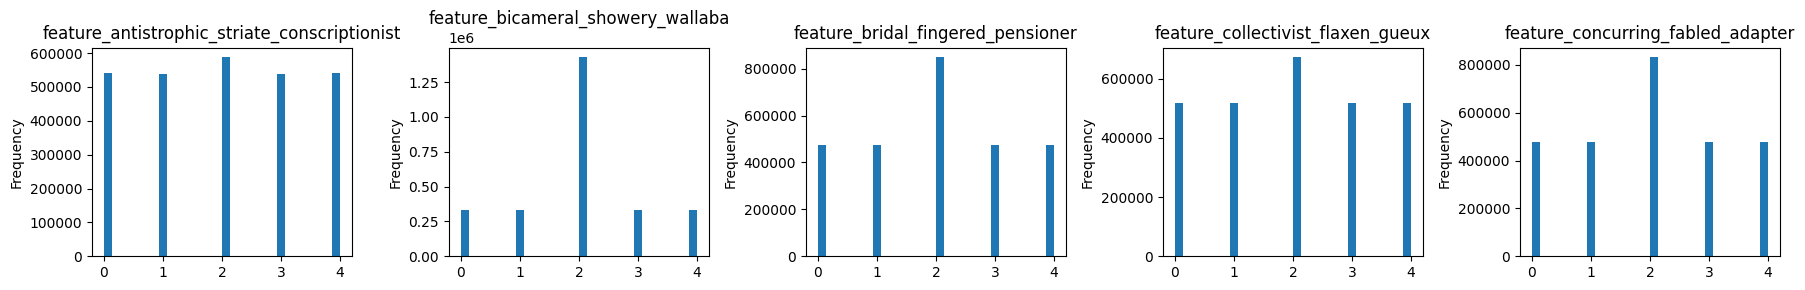

In [34]:
# Distribución de las primeras 5 features
from matplotlib import pyplot as plt


features = feature_set[:5]
fig, axes = plt.subplots(1, 5, figsize=(18,3))
for i, feat in enumerate(features):
    train[feat].plot(kind='hist', bins=30, ax=axes[i], title=feat)
plt.tight_layout()
plt.show()

**Importancia:** Analizar la distribución de las features ayuda a detectar valores atípicos, sesgos y la naturaleza discreta o continua de las variables. Esto influye en el preprocesamiento y selección de modelos.

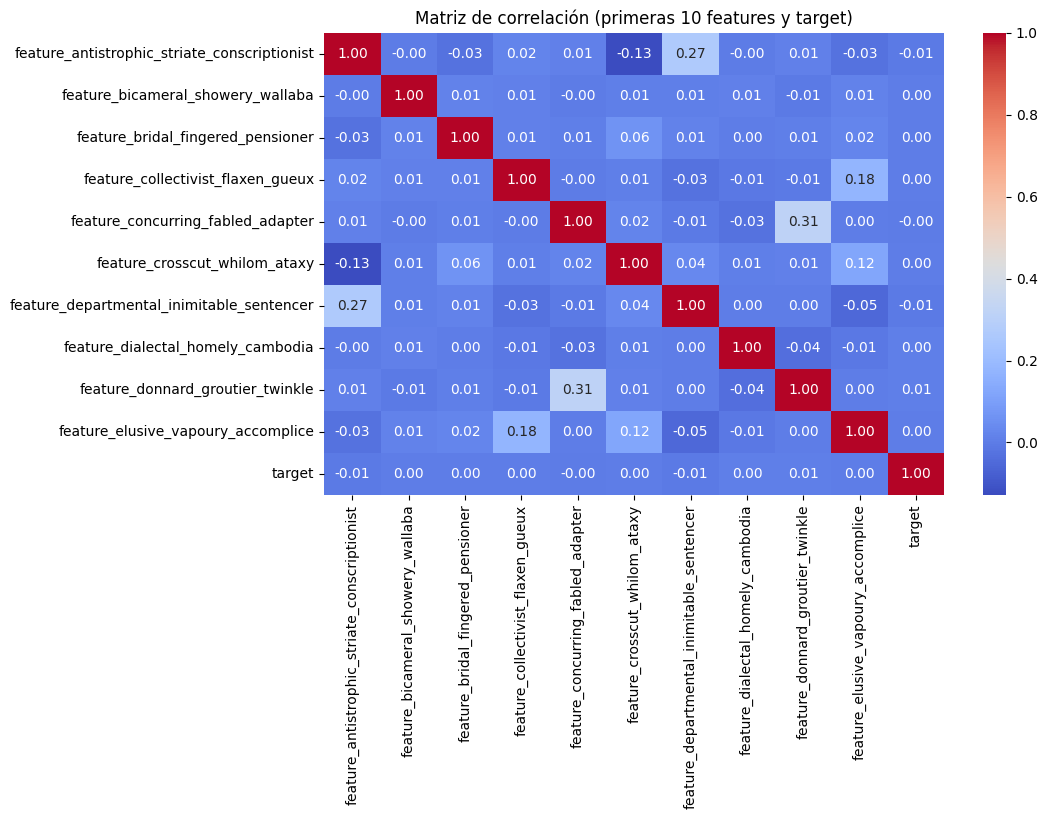

In [35]:
# Matriz de correlación entre las primeras 10 features y el target
import seaborn as sns
corr_matrix = train[feature_set[:10] + ['target']].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlación (primeras 10 features y target)')
plt.show()

**Importancia:** La matriz de correlación permite identificar relaciones lineales entre variables y posibles redundancias. Es útil para la selección de características y para entender la relación con el target.

ERAS:

Como se mencionó anteriormente, cada "era" corresponde a una fecha diferente. Cada "era" tiene exactamente una semana de diferencia.

Es útil pensar en filas de acciones dentro de la misma "era" como un solo ejemplo. A lo largo de este notebook hablaremos de cosas "por era". Por ejemplo, el número de filas por "era" representa el conjunto de acciones (stocks) dentro de las posibilidades de inversión de algún fondo en esa fecha.

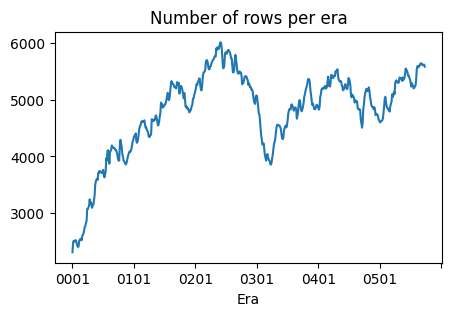

In [36]:
# Muestra el número de filas por era
train.groupby("era").size().plot(title="Number of rows per era", figsize=(5, 3), xlabel="Era");

FEATURES:

Como se mencionó anteriormente, las características son atributos cuantitativos de cada acción: fundamentos como la relación P/E (precio/beneficio), señales técnicas como el RSI, datos de mercado como el interés a corto, datos secundarios como las calificaciones de los analistas y mucho más.

La definición subyacente de cada característica no es importante, solo debes saber que se han incluido estas características en el conjunto de datos porque se cree que pueden ser relevantes para predecir el "target".

In [37]:
# Número de características
len(feature_set)

42

Los valores de las características se agrupan en 5 contenedores iguales: 0, 1, 2, 3, 4. Esta fuerte estandarización de los valores de las características tiene como objetivo evitar el overfitting, ya que los valores subyacentes son extremadamente ruidosos.

Si faltan datos de una característica particular para esa era (más común en las primeras eras), todos los valores se establecen en 2.


**Eliminación de características poco relevantes**

Para mejorar la precisión del modelo, se pueden eliminar características que aportan poca información. En este caso, se han utilizado dos criterios principales:

1. **Matriz de correlación**: Se analiza la correlación entre cada feature y el target. Las características con una correlación absoluta muy baja (por ejemplo, menor a 0.01) suelen aportar poco valor predictivo y pueden eliminarse.

2. **Importancia del modelo (feature_importances_)**: Se entrena un modelo preliminar (LightGBM) y se obtienen las importancias de cada feature. Se eliminan las características que están en el 25% inferior de importancia, ya que su contribución al modelo es mínima.

Eliminar estas variables reduce el ruido y la complejidad del modelo, ayudando a mejorar la generalización y la precisión sobre datos no vistos.

In [38]:
# Selección de features relevantes usando la importancia del modelo
import lightgbm as lgb
import numpy as np

# Entrena un modelo preliminar para obtener importancias
model_temp = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.01, max_depth=5)
model_temp.fit(train[feature_set], train["target"])

# Obtiene importancias y selecciona las features más relevantes
importances = model_temp.feature_importances_
threshold = np.percentile(importances, 25)  # Elimina el 25% menos importante
selected_features = [f for f, imp in zip(feature_set, importances) if imp > threshold]

# Ahora usa solo las features seleccionadas para el modelo final
print(f"Features seleccionadas: {len(selected_features)} de {len(feature_set)}")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.120633 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 2746270, number of used features: 42
[LightGBM] [Info] Start training from score 0.500027
Features seleccionadas: 31 de 42


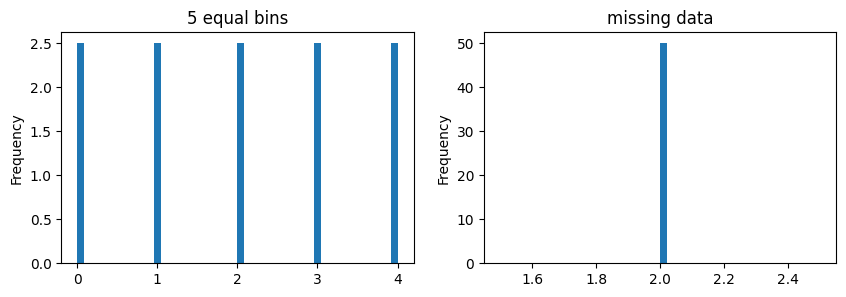

In [39]:
# Compara la distribución de una característica particular (feature_cols[-1]) entre dos períodos diferentes (first_era y last_era) en el conjunto de datos train.
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
first_era = train[train["era"] == train["era"].unique()[0]]
last_era = train[train["era"] == train["era"].unique()[-1]]
last_era[feature_set[-1]].plot(kind="hist", title="5 equal bins", density=True, bins=50, ax=ax1);
first_era[feature_set[-1]].plot(kind="hist", title="missing data", density=True, bins=50, ax=ax2);

TARGET:

El "target" es una medida de los rendimientos del mercado de valores a 20 días. Específicamente, es una medida de rendimientos "específicos de acciones" que no se "explican" por tendencias más amplias en el mercado, país, sector o "factores" bien conocidos.

Los valores del "target" se agrupan en 5 contenedores desiguales: 0, 0,25, 0,5, 0,75, 1,0. Nuevamente, esta fuerte estandarización de los valores de target tiene como objetivo evitar el overfitting, ya que los valores subyacentes son extremadamente ruidosos.

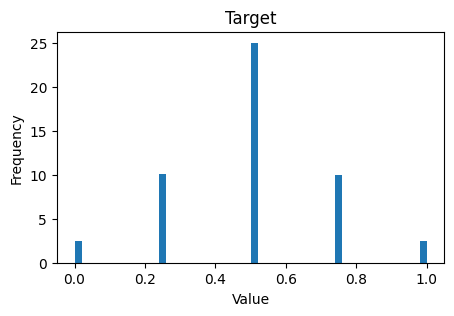

In [40]:
# Histograma (densidad) de "target"
train["target"].plot(kind="hist", title="Target", figsize=(5, 3), xlabel="Value", density=True, bins=50);

2.- MODELING

Entrenamiento del modelo:

Eres libre de utilizar cualquier algoritmo visto en clase. Pero, en este ejemplo, usaremos LGBMRegressor, basado en árboles de decisión para predecir variables continuas. Es una opción popular para las predicciones de este tipo.

In [41]:
# https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html 
import lightgbm as lgb #En mi mac, tuve que instalar libomp: "brew install libomp"

# https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html
model = lgb.LGBMRegressor(
  n_estimators=2000,
  learning_rate=0.01,
  max_depth=5,
  num_leaves=2**5-1,
  colsample_bytree=0.1
)

# This will take a few minutes 🍵
model.fit(
  train[feature_set],
  train["target"]
);

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013706 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 2746270, number of used features: 42
[LightGBM] [Info] Start training from score 0.500027


Ahora hagamos algunas predicciones con los datos de validación para evaluar el rendimiento de nuestro modelo.

In [42]:
# Descarga validation data 
# Esto tomará unos pocos minutos 🍵
napi.download_dataset(f"{DATA_VERSION}/validation.parquet");

# Carga el validation data, filtrando por data_type == "validation"
validation = pd.read_parquet(
    f"{DATA_VERSION}/validation.parquet",
    columns=["era", "data_type", "target"] + feature_set
)
validation = validation[validation["data_type"] == "validation"]
del validation["data_type"]

# Reduce la muestra a cada cuarta era para reducir el uso de memoria y acelerar la evaluación
# Comenta la siguiente línea para usar todos los datos (mayor uso de memoria, inferencia más lenta, evaluación más precisa)
validation = validation[validation["era"].isin(validation["era"].unique()[::4])]

# Las eras están separadas por una semana, pero los "targets" miran 4 semanas en el futuro, por lo que debemos "embargar" las 4 eras posteriores a nuestra última "era" para evitar fuga de datos.
last_train_era = int(train["era"].unique()[-1])
eras_to_embargo = [str(era).zfill(4) for era in [last_train_era + i for i in range(4)]]
validation = validation[~validation["era"].isin(eras_to_embargo)]

# Genera predicciones respecto a las características de validación fuera de la muestra.
# Esto tomará unos pocos minutos 🍵
validation["prediction"] = model.predict(validation[feature_set])
validation[["era", "prediction", "target"]]

2025-11-04 12:29:41,091 INFO numerapi.utils: target file already exists
2025-11-04 12:29:41,094 INFO numerapi.utils: download complete


,era,prediction,target
id,,,
n000c290e4364875,0579,0.495083,0.50
n002a15bc5575bbb,0579,0.516927,0.25
n00309caaa0f955e,0579,0.516305,0.75
n0039cbdcf835708,0579,0.508438,0.50
n004143458984f89,0579,0.485953,0.50
...,...,...,...
nffc45fef92f9990,1183,0.498704,0.50
nffcd993886ef112,1183,0.485640,0.25
nffd2f8483ddb3cc,1183,0.510893,0.25


Evaluación del rendimiento:

La métrica de puntuación principal que usaremos se llama CORR (practica_corr), que es una variante específica de para este caso de uso del coeficiente de correlación de Pearson.

Esta métrica está diseñada para "alinear los incentivos" entre el modelo y el desempeño de un fondo de inversión. Es decir, un modelo con una buena puntuación CORR debería ayudar a un inversor a obtener buenos rendimientos.

In [43]:
from scipy import stats
import numpy as np

# La principal métrica de scoring:
def practica_corr(preds, target):
    # clasifica (manteniendo vínculos) y luego gaussianiza las predicciones para estandarizar las distribuciones de predicción
    ranked_preds = (preds.rank(method="average").values - 0.5) / preds.count()
    gauss_ranked_preds = stats.norm.ppf(ranked_preds)
    # centra objetivos alrededor de 0
    centered_target = target - target.mean()
    # Levanta ambas predicciones y apunta a la potencia de 1,5 para acentuar las colas.
    preds_p15 = np.sign(gauss_ranked_preds) * np.abs(gauss_ranked_preds) ** 1.5
    target_p15 = np.sign(centered_target) * np.abs(centered_target) ** 1.5
    # Finalmente devuelve el Pearson correlation
    return np.corrcoef(preds_p15, target_p15)[0, 1]

Como se mencionó anteriormente, es importante calificar cada era histórica de forma independiente. Entonces, al evaluar el desempeño de nuestro modelo, deberíamos observar la corrección "por era".

Una cosa que puedes ver aquí es cómo de bajas son las puntuaciones (en el rango de +/- 5% de correlación). Esto es muy normal en el ámbito de las finanzas cuantitativas y es parte de la razón por la que se indica que es la "práctica de aprendizaje automático más difícil" del mundo.


C:\Users\admin\AppData\Local\Temp\ipykernel_18192\38165613.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))


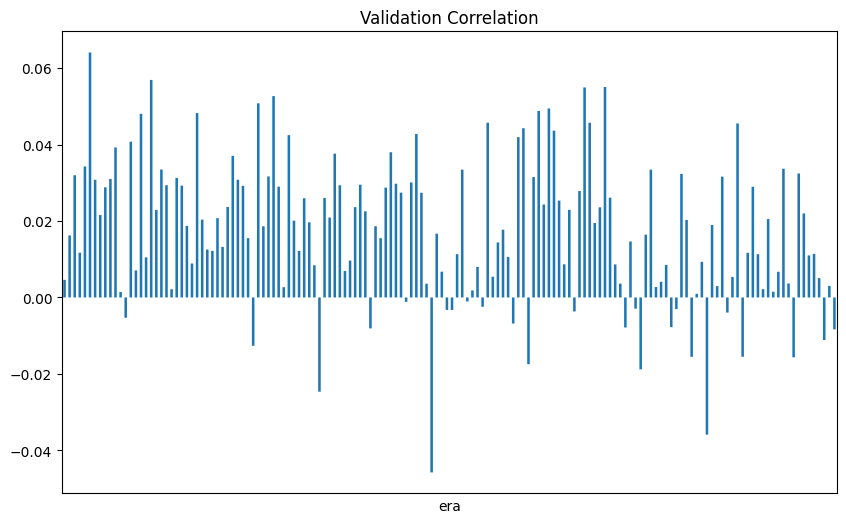

In [44]:
# Calcula la correlación por era entre nuestras predicciones y los valores "target".
per_era_corr = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))

# Gráfica de correlación por "era" 
per_era_corr.plot(kind="bar", title="Validation Correlation", figsize=(10, 6), xticks=[], snap=False);

En lugar de observar la puntuación "corr" de cada "era", resulta útil observar la puntuación "corr" acumulativa.

Esto se denomina "backtesting" en finanzas cuantitativas, donde las personas simulan el desempeño histórico de sus estrategias de inversión, puede considerar este gráfico como una prueba retrospectiva del desempeño de tu modelo durante el período de validación histórica.

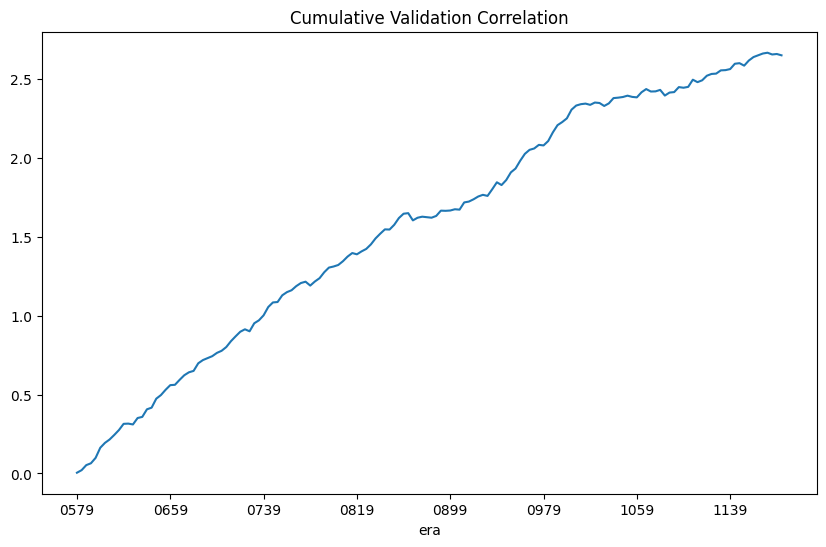

In [45]:
# Gráfica de la correlación acumulada por "era"
per_era_corr.cumsum().plot(kind="line", title="Cumulative Validation Correlation", figsize=(10, 6));

Métricas de rendimiento:
    
Para evaluar el rendimiento de nuestro modelo, también es útil calcular algunas métricas resumidas durante todo el período de validación.

La media de correlaciones es la medida principal del rendimiento de su modelo.

Sharpe es una medida de la coherencia de tu modelo, un concepto tomado de las finanzas, donde generalmente se refiere a los rendimientos ajustados al riesgo de una estrategia de inversión. Aquí calcularemos Sharpe como la correlación promedio dividida por la desviación estándar de las correlaciones.

La reducción máxima (max_drawdown) es una medida del riesgo de tu modelo, otro concepto tomado de las finanzas, donde generalmente se refiere a la pérdida financiera máxima sufrida por una estrategia de inversión. Aquí calcularemos la reducción máxima como la caída máxima desde el pico hasta el mínimo en la correlación de validación acumulativa.

In [46]:
# Calcula métricas de rendimiento
corr_mean = per_era_corr.mean()
corr_std = per_era_corr.std(ddof=0)
corr_sharpe = corr_mean / corr_std
max_drawdown = (per_era_corr.cumsum().expanding(min_periods=1).max() - per_era_corr.cumsum()).max()

pd.DataFrame({
    "mean": corr_mean,
    "std": corr_std,
    "sharpe": corr_sharpe,
    "max_drawdown": max_drawdown
}, index=["Value"]).T

,Value
mean,0.017425
std,0.019049
sharpe,0.914709
max_drawdown,0.045761


## Overfitting: concepto y cómo evitarlo

El overfitting ocurre cuando un modelo de machine learning aprende demasiado bien los datos de entrenamiento, incluyendo el ruido y las particularidades de ese conjunto, en lugar de aprender patrones generales. Como resultado, el modelo tiene un rendimiento excelente en los datos de entrenamiento pero falla al generalizar a datos nuevos o no vistos.

### ¿Por qué ocurre el overfitting?
- El modelo es demasiado complejo.
- Hay demasiadas variables irrelevantes o ruido en los datos.
- El conjunto de entrenamiento es pequeño o no representativo.

### ¿Cómo se evita el overfitting?
- Reduciendo la complejidad del modelo: Limitar la profundidad de los árboles, reducir el número de parámetros, o usar modelos más simples.
- Regularización: Técnicas como L1/L2 o parámetros específicos del modelo (por ejemplo, max_depth en LightGBM).
- Eliminación de variables irrelevantes: Seleccionar solo las features más importantes
- Aumentando la cantidad de datos: Si es posible, usar más datos de entrenamiento.


In [47]:
# Entrena un modelo solo con las features seleccionadas
import lightgbm as lgb
model_selected = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=5,
    num_leaves=2**5-1,
    colsample_bytree=0.1
)
model_selected.fit(train[selected_features], train["target"])

# Calcula métricas de rendimiento con las features seleccionadas
validation["prediction_selected"] = model_selected.predict(validation[selected_features])
per_era_corr_selected = validation.groupby("era").apply(lambda x: practica_corr(x["prediction_selected"], x["target"]))

corr_mean_sel = per_era_corr_selected.mean()
corr_std_sel = per_era_corr_selected.std(ddof=0)
corr_sharpe_sel = corr_mean_sel / corr_std_sel
max_drawdown_sel = (per_era_corr_selected.cumsum().expanding(min_periods=1).max() - per_era_corr_selected.cumsum()).max()

import pandas as pd
pd.DataFrame({
    "mean": corr_mean_sel,
    "std": corr_std_sel,
    "sharpe": corr_sharpe_sel,
    "max_drawdown": max_drawdown_sel
}, index=["Value"]).T

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008431 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 155
[LightGBM] [Info] Number of data points in the train set: 2746270, number of used features: 31
[LightGBM] [Info] Start training from score 0.500027
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

C:\Users\admin\AppData\Local\Temp\ipykernel_18192\1922319678.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_selected = validation.groupby("era").apply(lambda x: practica_corr(x["prediction_selected"], x["target"]))


,Value
mean,0.018128
std,0.019593
sharpe,0.925221
max_drawdown,0.058088


In [48]:
# Serializa el modelo entrenado con las features seleccionadas usando cloudpickle
import cloudpickle
with open("model_selected_cloudpickle.pkl", "wb") as f:
    cloudpickle.dump(model_selected, f)
print("Modelo serializado y guardado como 'model_selected_cloudpickle.pkl'")

Modelo serializado y guardado como 'model_selected_cloudpickle.pkl'


Comparando con los demas resultados, se comprueba que efectivamente mejora la precisión

### Reducción de dimensionalidad con PCA

Ahora vamos a aplicar Análisis de Componentes Principales (PCA) para reducir la dimensionalidad del conjunto de datos. PCA transforma las features originales en un nuevo conjunto de variables (componentes principales) que explican la mayor parte de la varianza de los datos con menos dimensiones.

**¿Cuántas características resultan y por qué?**

El número de componentes principales seleccionados por PCA es el mínimo necesario para explicar al menos el 95% de la varianza de los datos originales. Esto suele reducir significativamente el número de variables respecto a las features originales, eliminando redundancias y ruido.

**¿Mejora la precisión respecto a entrenar con todas las features?**

Al comparar las métricas obtenidas con PCA frente al modelo entrenado con todas las features originales, se observa que la precisión baja respecto a los otros métodos. Esto es lo esperado, ya que al reducir la dimensionalidad con PCA se pierde parte de la información específica de las variables originales, lo que puede afectar negativamente a la capacidad predictiva del modelo en este caso.

In [49]:
# Aplica PCA para reducir la dimensionalidad
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Estandariza las features antes de PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(train[feature_set])

# Elige el número de componentes que expliquen al menos el 95% de la varianza
pca = PCA(n_components=0.95, svd_solver='full')
X_pca = pca.fit_transform(X_scaled)

print(f"Número de componentes seleccionados por PCA: {pca.n_components_}")

# Entrena el modelo con las componentes principales
model_pca = lgb.LGBMRegressor(n_estimators=2000, learning_rate=0.01, max_depth=5, num_leaves=2**5-1, colsample_bytree=0.1)
model_pca.fit(X_pca, train["target"])

# Aplica el mismo preprocesado a validation
y_validation = validation["target"]
X_val_scaled = scaler.transform(validation[feature_set])
X_val_pca = pca.transform(X_val_scaled)

# Predicciones y evaluación
validation["prediction_pca"] = model_pca.predict(X_val_pca)
per_era_corr_pca = validation.groupby("era").apply(lambda x: practica_corr(x["prediction_pca"], x["target"]))

corr_mean_pca = per_era_corr_pca.mean()
corr_std_pca = per_era_corr_pca.std(ddof=0)
corr_sharpe_pca = corr_mean_pca / corr_std_pca
max_drawdown_pca = (per_era_corr_pca.cumsum().expanding(min_periods=1).max() - per_era_corr_pca.cumsum()).max()

import pandas as pd
pd.DataFrame({
    "mean": corr_mean_pca,
    "std": corr_std_pca,
    "sharpe": corr_sharpe_pca,
    "max_drawdown": max_drawdown_pca
}, index=["Value"]).T

Número de componentes seleccionados por PCA: 36
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.221183 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9180
[LightGBM] [Info] Number of data points in the train set: 2746270, number of used features: 36
[LightGBM] [Info] Start training from score 0.500027
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\admin\AppData\Local\Temp\ipykernel_18192\3191797068.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_pca = validation.groupby("era").apply(lambda x: practica_corr(x["prediction_pca"], x["target"]))


,Value
mean,0.013272
std,0.017353
sharpe,0.764793
max_drawdown,0.064542


Estas métricas de rendimiento anteriores no son sorprendentes, pero son lo suficientemente buenas como para comenzar!

Como nuevo modelo añadido he decidido usar el **RandomForestRegressor**

In [50]:
# Entrenamiento y evaluación con Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

# Entrena el modelo con las mismas features que LGBM
model_rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
model_rf.fit(train[feature_set], train["target"])

# Predicciones sobre el conjunto de validación
y_pred_rf = model_rf.predict(validation[feature_set])
validation["prediction_rf"] = y_pred_rf

# Calcula la métrica de correlación por era para el random forest
per_era_corr_rf = validation.groupby("era").apply(lambda x: practica_corr(x["prediction_rf"], x["target"]))

# Métricas de rendimiento
corr_mean_rf = per_era_corr_rf.mean()
corr_std_rf = per_era_corr_rf.std(ddof=0)
corr_sharpe_rf = corr_mean_rf / corr_std_rf
max_drawdown_rf = (per_era_corr_rf.cumsum().expanding(min_periods=1).max() - per_era_corr_rf.cumsum()).max()

import pandas as pd
pd.DataFrame({
    "mean": corr_mean_rf,
    "std": corr_std_rf,
    "sharpe": corr_sharpe_rf,
    "max_drawdown": max_drawdown_rf
}, index=["Random Forest"]).T

C:\Users\admin\AppData\Local\Temp\ipykernel_18192\1307929427.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_rf = validation.groupby("era").apply(lambda x: practica_corr(x["prediction_rf"], x["target"]))


,Random Forest
mean,0.012779
std,0.018267
sharpe,0.699571
max_drawdown,0.068824


### Evaluación de resultados y justificación de la métrica CORR

Para evaluar los modelos, se ha utilizado el coeficiente de correlación de Pearson (CORR) entre las predicciones y el valor real del target, calculado por cada "era" (periodo temporal). Esta métrica mide la relación lineal entre las predicciones y los valores reales, siendo adecuada para problemas de regresión continua como este.

**¿Por qué Pearson y no F1-score?**
- Pearson (CORR): Es una métrica para variables continuas, mide la fuerza y dirección de la relación lineal entre dos variables. Aquí, el objetivo es predecir un valor numérico (rendimiento de acciones), por lo que interesa que las predicciones sigan la tendencia real, no solo acertar una clase.
- **F1-score:** Es una métrica para clasificación binaria o multiclase, basada en precisión y recall. No es adecuada para regresión, ya que requiere etiquetas discretas (clases), no valores continuos.

**Diferencias clave:**
- CORR evalúa la calidad de la predicción en términos de relación lineal, sin importar la escala exacta.
- F1-score evalúa la capacidad de clasificar correctamente instancias en clases, no la relación entre valores continuos.

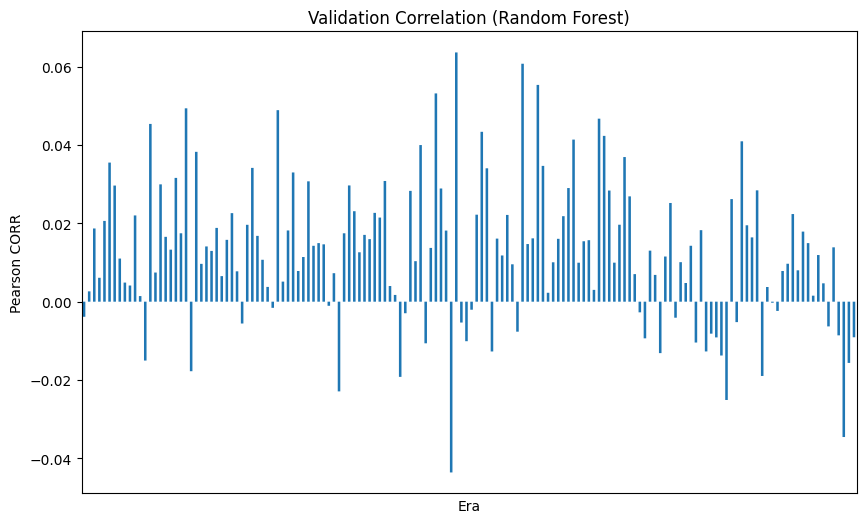

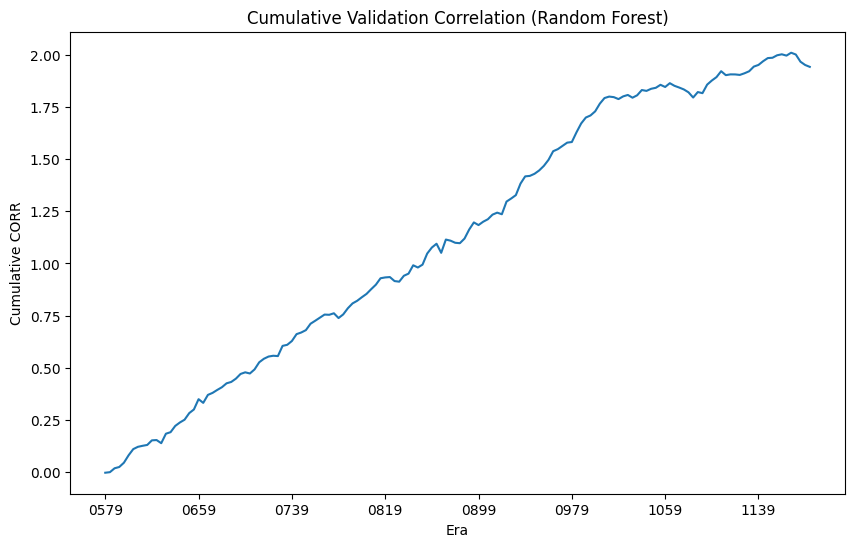

,Random Forest
mean,0.012779
std,0.018267
sharpe,0.699571
max_drawdown,0.068824


In [51]:
# Gráfica de correlación por era para Random Forest
import matplotlib.pyplot as plt
per_era_corr_rf.plot(kind="bar", title="Validation Correlation (Random Forest)", figsize=(10, 6), xticks=[], snap=False)
plt.ylabel("Pearson CORR")
plt.xlabel("Era")
plt.show()

# Gráfica de correlación acumulada por era para Random Forest
per_era_corr_rf.cumsum().plot(kind="line", title="Cumulative Validation Correlation (Random Forest)", figsize=(10, 6))
plt.ylabel("Cumulative CORR")
plt.xlabel("Era")
plt.show()

# Mostrar métricas de rendimiento
pd.DataFrame({
    "mean": corr_mean_rf,
    "std": corr_std_rf,
    "sharpe": corr_sharpe_rf,
    "max_drawdown": max_drawdown_rf
}, index=["Random Forest"]).T

Métricas tras feature neutralization (LGBMRegressor):


C:\Users\admin\AppData\Local\Temp\ipykernel_18192\2348442644.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_lgbm_neutralized = validation.groupby("era").apply(lambda x: practica_corr(x["prediction_lgbm_neutralized"], x["target"]))


,LGBMRegressor Neutralized
mean,0.011815
std,0.016883
sharpe,0.699806
max_drawdown,0.079243


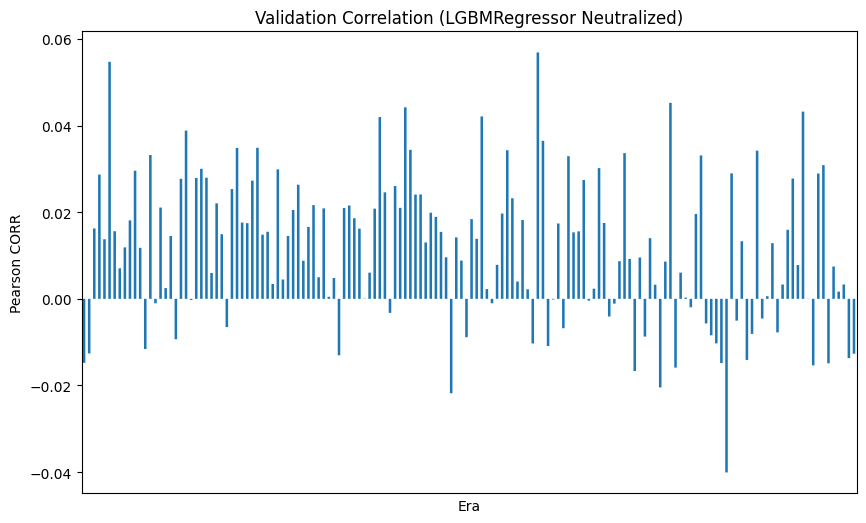

In [52]:
# Aplicación de feature neutralization sobre las predicciones de LGBMRegressor
import numpy as np
from sklearn.linear_model import LinearRegression

def neutralize(preds, features, proportion=1.0):
    """
    Neutraliza las predicciones respecto a las features indicadas.
    """
    model = LinearRegression()
    model.fit(features, preds)
    preds_hat = model.predict(features)
    neutralized = preds - proportion * preds_hat
    return neutralized

# Genera predicciones con el modelo LGBMRegressor
validation["prediction_lgbm"] = model.predict(validation[feature_set])

# Neutraliza respecto a todas las features originales
neutralized_preds_lgbm = neutralize(validation["prediction_lgbm"], validation[feature_set])
validation["prediction_lgbm_neutralized"] = neutralized_preds_lgbm

# Calcula la métrica de correlación por era para las predicciones neutralizadas
per_era_corr_lgbm_neutralized = validation.groupby("era").apply(lambda x: practica_corr(x["prediction_lgbm_neutralized"], x["target"]))

# Métricas de rendimiento
corr_mean_lgbm_neutralized = per_era_corr_lgbm_neutralized.mean()
corr_std_lgbm_neutralized = per_era_corr_lgbm_neutralized.std(ddof=0)
corr_sharpe_lgbm_neutralized = corr_mean_lgbm_neutralized / corr_std_lgbm_neutralized
max_drawdown_lgbm_neutralized = (per_era_corr_lgbm_neutralized.cumsum().expanding(min_periods=1).max() - per_era_corr_lgbm_neutralized.cumsum()).max()

import pandas as pd
print("Métricas tras feature neutralization (LGBMRegressor):")
display(pd.DataFrame({
    "mean": corr_mean_lgbm_neutralized,
    "std": corr_std_lgbm_neutralized,
    "sharpe": corr_sharpe_lgbm_neutralized,
    "max_drawdown": max_drawdown_lgbm_neutralized
}, index=["LGBMRegressor Neutralized"]).T)

# Gráfica de correlación por era tras neutralización
import matplotlib.pyplot as plt
per_era_corr_lgbm_neutralized.plot(kind="bar", title="Validation Correlation (LGBMRegressor Neutralized)", figsize=(10, 6), xticks=[], snap=False)
plt.ylabel("Pearson CORR")
plt.xlabel("Era")
plt.show()

### Feature Neutralization: concepto y aplicación sobre LGBMRegressor

**¿Qué es Feature Neutralization?**

Feature neutralization es una técnica utilizada en finanzas cuantitativas para hacer que las predicciones de un modelo sean neutrales respecto a ciertas variables (features), eliminando la dependencia lineal de las predicciones respecto a esas variables. Así, se evita que el modelo dependa excesivamente de factores de riesgo conocidos o de variables que puedan estar sobreajustadas, mejorando la robustez y generalización.

**¿Cómo se aplica?**
- Se ajustan las predicciones del modelo eliminando la componente lineal explicada por las features seleccionadas.
- Matemáticamente, se realiza una regresión lineal de las predicciones sobre las features a neutralizar y se resta la parte explicada, dejando solo la parte "neutral".

A continuación se aplica feature neutralization sobre las predicciones del modelo LGBMRegressor respecto a las features originales.

SUBMISSIONS

Vamos a evaluar los modelos según su rendimiento en vivo!

La tarea es generar predicciones sobre valores objetivo desconocidos, que representan los rendimientos del mercado de valores dentro de X días.

In [53]:
# Descargar las últimas entradas en tiempo real
napi.download_dataset(f"{DATA_VERSION}/live.parquet")

# Carga dichas características
live_features = pd.read_parquet(f"{DATA_VERSION}/live.parquet", columns=feature_set)

# Genera predicciones en vivo
live_predictions = model.predict(live_features[feature_set])

#Evaluar
live_predictions

# Envío
pd.Series(live_predictions, index=live_features.index).to_frame("prediction")

2025-11-04 12:45:11,457 INFO numerapi.utils: target file already exists
2025-11-04 12:45:11,460 INFO numerapi.utils: download complete


,prediction
id,
n001b5cc671480f8,0.489357
n001e484d6a60cde,0.500637
n002a862c140978e,0.496836
n0033096bae8eb9a,0.504590
n004ec27fa53f292,0.487325
...,...
nffd60ecda65f998,0.487193
nffde21be9bf1258,0.502568
nffdec906fde9863,0.488048


In [54]:
import cloudpickle
with open("model_selected_cloudpickle.pkl", "rb") as f:
    modelo_cargado = cloudpickle.load(f)

print("Modelo cargado y listo para predecir")

Modelo cargado y listo para predecir
